# Complete Data Pipeline: Multi-Source Acquisition to ML-Ready Data

**Docker image**: `ml4t`

## Purpose
Wire together the chapter's components — multi-provider acquisition,
OHLC validation, source attribution, and efficient storage — into two
end-to-end pipelines: an equity pipeline that stitches WikiPrices
(1990-2018) with Yahoo (2018-now), and a crypto pipeline that consumes
the local Binance hourly perpetuals panel. The notebook then shows how
`ml4t.data.DataManager` does the same job in a fraction of the code.

## Learning Objectives
- Build a multi-source equity pipeline and validate at every boundary.
- Detect 24/7 coverage gaps and add session features for crypto data.
- Tag every row with its source so multi-source data is auditable.
- Replace the explicit pipeline with the `DataManager` + `Universe` +
  `HiveStorage` higher-level API that ships with `ml4t.data`.

## Book reference
Chapter 2, §2.3 (multi-source stitching + production pipelines). The
pipeline outputs feed the ETF and crypto-perps case studies.

## Prerequisites
- WikiPrices parquet under
  `ML4T_DATA_PATH/equities/market/us_equities/us_equities.parquet`.
- Crypto-perps hourly parquet loadable via `data.load_crypto_perps`.
- Live YahooFinance access (the equity pipeline calls it for the
  2018-now leg — same convention as `16_provider_comparison`).

## Note on universe choice
WikiPrices covers individual US stocks (~3,200 tickers, 1962-2018) but
**not** index ETFs. For the equity pipeline below the demo universe
uses three large-caps (AAPL, MSFT, JPM) so the WikiPrices-Yahoo stitch
is non-trivial; the ETF rotation case study itself uses Yahoo-only
from 2008 onwards (see `case_studies/etfs/`).

In [1]:
"""Complete Data Pipeline — Multi-source acquisition to ML-ready data."""

from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import polars as pl
from ml4t.data.providers import WikiPricesProvider, YahooFinanceProvider

from data import load_crypto_perps
from utils import DATA_DIR
from utils.paths import display_path, get_output_dir
from utils.style import COLORS, show_with_alt

### Declared parameters

`AS_OF_DATE` fixes the right-hand end of every window so the outputs are stable between
book editions rather than moving with the wall clock.

`WIKI_END_DATE` is the seam. The WikiPrices feed stopped on that date, so it is the
boundary the stitch filters on and the line the figure draws. It appears once here rather
than in each of the three places that need it.

The two gap thresholds encode a difference in kind rather than degree: an equity calendar
closes for weekends and holidays, and a perpetual futures market does not close at all, so
the same gap means an ordinary weekend on one panel and an outage on the other.

In [2]:
AS_OF_DATE = "2025-01-15"
WIKI_END_DATE = "2018-03-27"  # the last day the WikiPrices feed published
OVERLAP_START = "2018-03-01"  # the recent leg starts here so the two legs share dates

EQUITY_SYMBOLS = ["AAPL", "MSFT", "JPM"]
EQUITY_START = "1990-01-01"
EQUITY_MAX_GAP_DAYS = 5  # a longer gap than any holiday weekend produces

CRYPTO_SYMBOLS = ["BTCUSDT", "ETHUSDT"]
CRYPTO_START = "2024-01-01"
CRYPTO_MAX_GAP_HOURS = 1.5  # a 24/7 hourly panel should never exceed one bar
FUNDING_HOURS_UTC = [0, 8, 16]
RECENT_DAYS = 30  # window for the first crypto panel

In [3]:
print(f"Data path: {display_path(DATA_DIR)}")

Data path: <ML4T_DATA_PATH>


---

## 1. Pipeline Architecture

A production pipeline has three stages:

| Stage | Inputs | Outputs |
|-------|--------|---------|
| **Acquire** | Yahoo Finance, WikiPrices, Binance | raw OHLCV per source |
| **Process** | raw OHLCV | validated, normalized, tagged frames |
| **Store** | tagged frames | partitioned Parquet keyed by symbol/date |

Four design principles drive the rest of the notebook:

1. **Provider independence** — the orchestrator shouldn't care which
   source each row came from.
2. **Validate at boundaries** — every entry/exit point checks OHLC
   invariants, gap thresholds, and duplicate timestamps.
3. **Source attribution** — every row carries a `source` column so
   downstream debugging stays sane.
4. **Incremental updates** — re-runs fetch only what is new (the
   `DataManager` API in §5 handles this transparently).

---

## 2. Equity Pipeline

### The seam needs a rescale, not just a filter

Two things have to be reconciled at the boundary, and the first is mechanical. The two
providers disagree about time zones - one stamps its timestamps naive and the other stamps
them UTC-aware - so concatenating the legs raises rather than silently mixing two clocks.
That refusal is right, and it still has to be resolved: both are daily bars in UTC, so
converting to UTC and dropping the zone puts them on one clock without moving anything.

Both feeds publish adjusted prices, and they are adjusted for different sets of events.
WikiPrices back-adjusts only the splits that happened inside its own coverage window,
which ends in 2018. Yahoo back-adjusts every split up to today, including ones after that
date - Apple's four-for-one in 2020 among them. Filtering the two legs at the seam and
concatenating them therefore produces a series with a step in it, and the step is a
corporate action rather than a price move.

The fix is one number, and where it is measured matters more than it looks. Both legs are
already dividend-adjusted, so on any day *both* feeds quote, the ratio of their two closes
is the difference in adjustment basis and nothing else. Taking the ratio across the seam
instead - the last historical close against the first recent one - divides two different
days' prices, so the intervening market move rides along in the factor. That forces the
return across the seam to zero and pushes the same move into the rescaled volume.

So the recent leg is fetched from `OVERLAP_START`, before the seam rather than after it,
purely so the two legs share dates to measure on; the factor comes from the last day they
both quote, and the overlapping rows are then dropped from the historical side when the
legs are joined. Volume scales the other way - a four-for-one split quarters the price and
quadruples the share count - so the historical volume is divided by the same number.

The combine step asserts that the overlap was non-empty, because a fetch window that does
not overlap leaves the factor unset and the rescale silently skipped, which looks exactly
like a stitch that needed no rescale.

### Requirements

- **Universe**: AAPL, MSFT, JPM (chosen because they have full
  WikiPrices coverage; pure ETFs like SPY only have Yahoo data here).
- **History**: 1990-present (~35 years).
- **Frequency**: Daily.
- **Adjustments**: Split + dividend (total return).

### Combine Multi-Source Data

Wiki Prices ends at 2018-03-27; Yahoo Finance continues from there.
This function stitches the two sources at the boundary, tagging each
row with its origin for downstream auditability.

In [4]:
def _naive_utc(df: pl.DataFrame, column: str = "timestamp") -> pl.DataFrame:
    """Put `column` on a single clock: UTC, with the zone dropped.

    A provider that stamps naive is read as already UTC; one that stamps UTC-aware is
    converted and then stripped. Nothing moves in either case, and the two become concatenable.
    """
    if df[column].dtype.time_zone is None:
        return df
    return df.with_columns(pl.col(column).dt.convert_time_zone("UTC").dt.replace_time_zone(None))


def _combine_pipeline_sources(
    historical: pl.DataFrame | None,
    recent: pl.DataFrame | None,
    symbol: str,
    wiki_end: str = WIKI_END_DATE,
) -> pl.DataFrame:
    """Combine Wiki Prices and Yahoo Finance data at the provider boundary."""
    if historical is None and recent is None:
        raise ValueError(f"No data available for {symbol}")

    if historical is None:
        return _naive_utc(recent).with_columns(pl.lit("yahoo").alias("source"))

    if recent is None:
        return _naive_utc(historical).with_columns(pl.lit("wiki").alias("source"))

    historical = _naive_utc(historical)
    recent = _naive_utc(recent)

    wiki_end_dt = datetime.strptime(wiki_end, "%Y-%m-%d").date()

    # The factor comes from a shared date; see the markdown above for why not across the seam.
    overlap = (
        historical.select(pl.col("timestamp").dt.date().alias("day"), pl.col("close"))
        .join(
            recent.select(pl.col("timestamp").dt.date().alias("day"), pl.col("close")),
            on="day",
            suffix="_recent",
        )
        .sort("day")
    )
    if not overlap.height:
        raise ValueError(
            f"{symbol}: the two legs share no date, so the adjustment factor cannot be "
            "measured. Fetch the recent leg from before the seam."
        )
    wiki_close = overlap["close"][-1]
    yahoo_close = overlap["close_recent"][-1]
    if not (wiki_close and wiki_close > 0 and yahoo_close and yahoo_close > 0):
        raise ValueError(f"{symbol}: a close of zero or null on the shared date")
    scale = yahoo_close / wiki_close

    historical = historical.filter(pl.col("timestamp").dt.date() <= wiki_end_dt)
    recent = recent.filter(pl.col("timestamp").dt.date() > wiki_end_dt)

    historical = historical.with_columns(
        [
            (pl.col("open") * scale).alias("open"),
            (pl.col("high") * scale).alias("high"),
            (pl.col("low") * scale).alias("low"),
            (pl.col("close") * scale).alias("close"),
            (pl.col("volume") / scale).alias("volume"),
        ]
    )

    historical = historical.with_columns(pl.lit("wiki").alias("source"))
    recent = recent.with_columns(pl.lit("yahoo").alias("source"))

    common_cols = list(set(historical.columns) & set(recent.columns))
    combined = pl.concat([historical.select(common_cols), recent.select(common_cols)]).sort(
        "timestamp"
    )

    return combined

### Validate Pipeline Data

Check OHLC invariants, detect zero/negative prices, flag date gaps
beyond five calendar days, and catch duplicate timestamps.

In [5]:
def _validate_pipeline_data(df: pl.DataFrame, symbol: str) -> dict[str, Any]:
    """Run data quality validation checks on OHLCV data."""
    issues = []

    # OHLC invariants
    ohlc_valid = (
        (df["high"] >= df["low"]).all()
        and (df["high"] >= df["open"]).all()
        and (df["high"] >= df["close"]).all()
        and (df["low"] <= df["open"]).all()
        and (df["low"] <= df["close"]).all()
    )
    if not ohlc_valid:
        issues.append("OHLC invariant violations")

    # Zero/negative prices
    if (df["close"] <= 0).any():
        issues.append("Zero or negative prices")

    # Date gaps
    dates = df["timestamp"].sort().to_list()
    max_gap_days = max(
        (dates[i] - dates[i - 1]).days for i in range(1, len(dates)) if len(dates) > 1
    )

    if max_gap_days > EQUITY_MAX_GAP_DAYS:
        issues.append(f"Date gap of {max_gap_days} days")

    # Duplicate dates
    if df["timestamp"].n_unique() != len(df):
        issues.append(f"Duplicate dates: {len(df) - df['timestamp'].n_unique()}")

    return {
        "symbol": symbol,
        "n_rows": len(df),
        "date_range": (df["timestamp"].min(), df["timestamp"].max()),
        "max_gap_days": max_gap_days if len(dates) > 1 else 0,
        "issues": issues,
        "is_valid": len(issues) == 0,
    }

### Fetch Historical Data from Wiki Prices

Reads adjusted OHLCV from the Wiki Prices parquet, adapting to whichever
column-naming schema the on-disk file uses (`symbol`/`asset`/`ticker`).

In [6]:
def _fetch_wiki_historical(
    wiki_path: Path, symbol: str, start_date: str, end_date: str
) -> pl.DataFrame | None:
    """Fetch historical data from Wiki Prices parquet with schema auto-detection."""
    schema = set(pl.scan_parquet(wiki_path).collect_schema().names())
    start_dt = datetime.strptime(start_date, "%Y-%m-%d").date()
    end_dt = datetime.strptime(end_date, "%Y-%m-%d").date()

    # Determine entity and time column names from on-disk schema
    if "symbol" in schema:
        entity_col, time_col = "symbol", "timestamp"
    elif "asset" in schema:
        entity_col, time_col = "asset", "timestamp"
    else:
        entity_col, time_col = "ticker", "date"

    df = (
        pl.scan_parquet(wiki_path)
        .filter(
            (pl.col(entity_col) == symbol)
            & (pl.col(time_col) >= pl.lit(start_dt))
            & (pl.col(time_col) <= pl.lit(end_dt))
        )
        .select(
            [
                pl.col(time_col).cast(pl.Datetime("us")).alias("timestamp"),
                pl.col("adj_open").alias("open"),
                pl.col("adj_high").alias("high"),
                pl.col("adj_low").alias("low"),
                pl.col("adj_close").alias("close"),
                pl.col("adj_volume").alias("volume"),
            ]
        )
        .sort("timestamp")
        .collect()
    )
    return df if len(df) > 0 else None

### Process a Single ETF Symbol

Drives one symbol through fetch, combine, validate, and tag. Returns
a result dict with the data and validation report.

In [7]:
def _process_etf_symbol(
    pipeline: "ETFMomentumPipeline", symbol: str, start_date: str = EQUITY_START
) -> dict[str, Any]:
    """Process a single symbol through the complete pipeline."""
    print(f"\n{symbol}:")

    # Stage 1: Fetch
    historical = pipeline.fetch_historical(symbol, start_date)
    # Start the recent leg far enough back to overlap the historical one. The overlap is what
    # the rescale factor is measured on; without it there is no shared date to measure.
    recent = pipeline.fetch_recent(symbol, OVERLAP_START)

    wiki_rows = len(historical) if historical is not None else 0
    yahoo_rows = len(recent) if recent is not None else 0
    print(f"  Fetched: Wiki={wiki_rows:,}, Yahoo={yahoo_rows:,}")

    # Stage 2: Combine
    try:
        combined = pipeline.combine_sources(historical, recent, symbol)
    except ValueError as e:
        return {"symbol": symbol, "error": str(e)}

    # Stage 3: Validate
    validation = _validate_pipeline_data(combined, symbol)
    if validation["issues"]:
        for issue in validation["issues"]:
            print(f"  [WARN] {issue}")
        pipeline.stats["validation_errors"] += len(validation["issues"])
    else:
        print(f"  Validated: {len(combined):,} rows, no issues")

    # Stage 4: Add metadata
    combined = combined.with_columns(
        [pl.lit(symbol).alias("symbol"), pl.lit(datetime.now()).alias("processed_at")]
    )

    pipeline.stats["symbols_processed"] += 1
    pipeline.stats["total_rows"] += len(combined)

    return {"symbol": symbol, "data": combined, "validation": validation}

### Run ETF Pipeline

Iterates over the symbol universe, processing each through fetch/combine/validate,
then prints a summary of processed symbols, total rows, and validation issues.

In [8]:
def _run_etf_pipeline(
    pipeline: "ETFMomentumPipeline", symbols: list[str] | None = None
) -> dict[str, Any]:
    """Run the complete ETF pipeline for all symbols."""
    symbols = symbols or pipeline.UNIVERSE
    print("=" * 60)
    print("ETF Momentum Pipeline")
    print("=" * 60)
    print(f"Universe: {symbols}")

    results = {}
    for symbol in symbols:
        results[symbol] = pipeline.process_symbol(symbol)

    print("\n" + "-" * 60)
    print(
        f"Summary: {pipeline.stats['symbols_processed']} symbols, "
        f"{pipeline.stats['total_rows']:,} rows, "
        f"{pipeline.stats['validation_errors']} issues"
    )
    return results

### ETF Momentum Pipeline

Orchestrates multi-source fetch (Wiki Prices + Yahoo Finance),
data combination, validation, and metadata tagging for each symbol.

In [9]:
class ETFMomentumPipeline:
    """Equity pipeline: combines WikiPrices (1962-2018) with Yahoo Finance (2018-present).

    Demo universe uses individual stocks because WikiPrices does not include
    index ETFs. The book's ETF rotation case study uses Yahoo-only data from
    2008 onwards (see `case_studies/etfs/`).
    """

    UNIVERSE = EQUITY_SYMBOLS
    SEAM = WIKI_END_DATE  # the class keeps its own reference to the declared seam
    END_DATE = AS_OF_DATE

    def __init__(self, wiki_path: Path | None = None, storage_path: Path | None = None):
        """Initialize pipeline with data sources."""
        from utils import ML4T_DATA_PATH

        self.wiki_path = (
            wiki_path
            or ML4T_DATA_PATH / "equities" / "market" / "us_equities" / "us_equities.parquet"
        )
        self.storage_path = storage_path or get_output_dir(2, "etf_pipeline")
        self.yahoo_provider = YahooFinanceProvider()
        self.stats = {"symbols_processed": 0, "total_rows": 0, "validation_errors": 0}

    def fetch_historical(self, symbol: str, start_date: str) -> pl.DataFrame | None:
        """Fetch data from Wiki Prices (pre-2018)."""
        if not self.wiki_path.exists():
            raise FileNotFoundError(f"Wiki Prices parquet not found at {self.wiki_path}")
        return _fetch_wiki_historical(self.wiki_path, symbol, start_date, self.SEAM)

    def fetch_recent(self, symbol: str, start_date: str) -> pl.DataFrame | None:
        """Fetch data from Yahoo Finance (2018-present)."""
        df = self.yahoo_provider.fetch_ohlcv(
            symbol=symbol, start=start_date, end=self.END_DATE, frequency="1d"
        )
        return df if len(df) > 0 else None

    def combine_sources(
        self, historical: pl.DataFrame | None, recent: pl.DataFrame | None, symbol: str
    ) -> pl.DataFrame:
        """Combine Wiki Prices and Yahoo Finance data."""
        return _combine_pipeline_sources(historical, recent, symbol, self.SEAM)

    def process_symbol(self, symbol: str, start_date: str = EQUITY_START) -> dict[str, Any]:
        """Process a single symbol through the complete pipeline."""
        return _process_etf_symbol(self, symbol, start_date)

    def run(self, symbols: list[str] | None = None) -> dict[str, Any]:
        """Run the complete pipeline for all symbols."""
        return _run_etf_pipeline(self, symbols)

In [10]:
# Run the equity pipeline on the demo universe
etf_pipeline = ETFMomentumPipeline()
etf_results = etf_pipeline.run()

2026-09-10 13:05:30 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=yahoo


2026-09-10 13:05:30 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


ETF Momentum Pipeline
Universe: ['AAPL', 'MSFT', 'JPM']

AAPL:
2026-09-10 13:05:30 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=1d name=YahooFinanceProvider provider=yahoo start=2018-03-01 symbol=AAPL


2026-09-10 13:05:30 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2018-03-01 symbol=AAPL


2026-09-10 13:05:30 [info     ] Successfully fetched data      rows=1730 symbol=AAPL


...

  Fetched: Wiki=7,114, Yahoo=1,730
  [WARN] Date gap of 7 days

JPM:
2026-09-10 13:05:30 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=1d name=YahooFinanceProvider provider=yahoo start=2018-03-01 symbol=JPM


2026-09-10 13:05:30 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2018-03-01 symbol=JPM


2026-09-10 13:05:30 [info     ] Successfully fetched data      rows=1730 symbol=JPM


2026-09-10 13:05:30 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=1730 symbol=JPM


  Fetched: Wiki=7,114, Yahoo=1,730
  [WARN] Date gap of 7 days

------------------------------------------------------------
Summary: 3 symbols, 26,474 rows, 3 issues


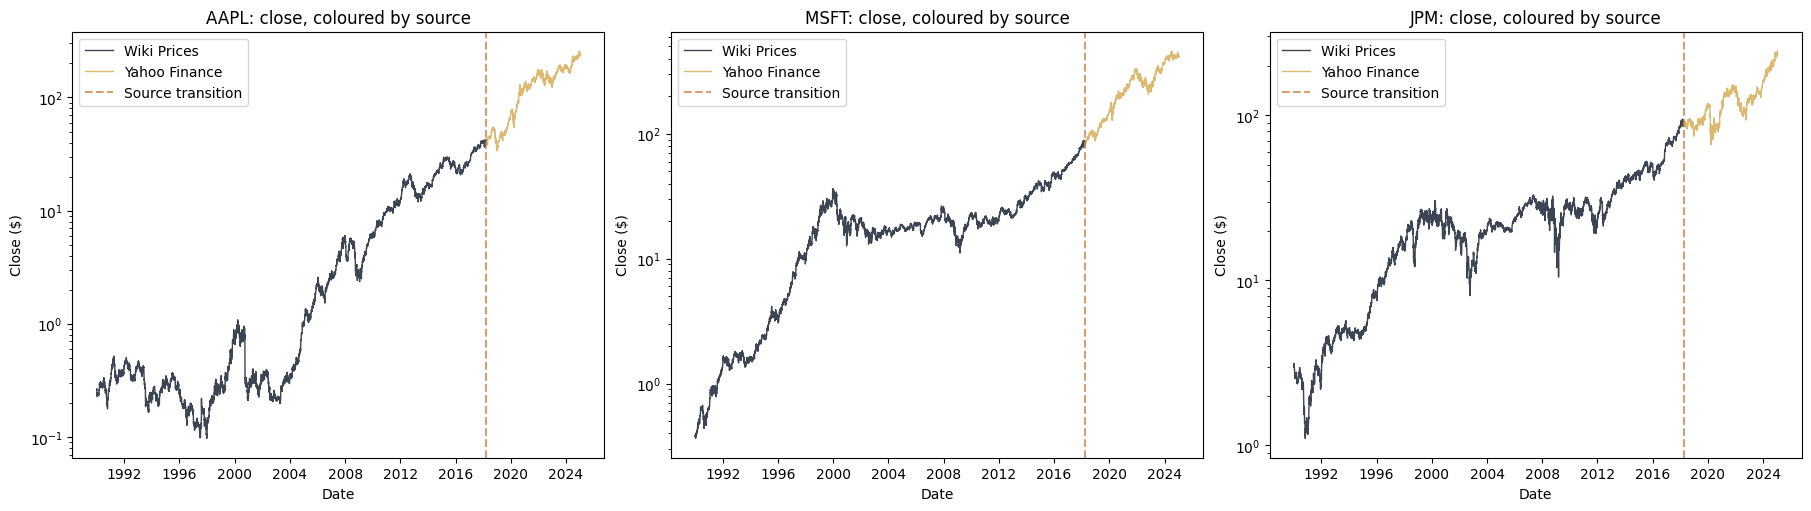

In [11]:
# Visualize the stitched data — one panel per symbol
fig, axes = plt.subplots(
    1, len(etf_results), figsize=(6 * len(etf_results), 5), constrained_layout=True, squeeze=False
)
for ax, (symbol, result) in zip(axes[0], etf_results.items(), strict=True):
    df = result["data"]
    for source, color in [("wiki", COLORS["blue"]), ("yahoo", COLORS["amber"])]:
        src = df.filter(pl.col("source") == source)
        label = "Wiki Prices" if source == "wiki" else "Yahoo Finance"
        if len(src) > 0:
            ax.plot(
                src["timestamp"].to_list(),
                src["close"].to_list(),
                label=label,
                alpha=0.8,
                linewidth=1,
                color=color,
            )
    ax.axvline(
        datetime.strptime(WIKI_END_DATE, "%Y-%m-%d"),
        color=COLORS["copper"],
        linestyle="--",
        alpha=0.7,
        label="Source transition",
    )
    ax.set_title(f"{symbol}: close, coloured by source")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close ($)")
    ax.legend(loc="upper left")
    ax.set_yscale("log")
show_with_alt(
    fig,
    "Three panels side by side, one per symbol, each showing a daily close on a logarithmic "
    "axis over three decades in two colours for the two sources, with a dashed vertical line "
    "at the source transition. In every panel the two coloured segments meet at that line "
    "with no visible step, and each series rises across the window.",
)

---

## 3. Case Study 2: Crypto Funding Rate Pipeline

### Requirements

- **Universe**: BTCUSDT, ETHUSDT (perpetual futures)
- **History**: 2020-present
- **Frequency**: Hourly OHLCV
- **Coverage**: 24/7 (no market hours)

### Validate 24/7 Coverage

Crypto markets run continuously, so we check for hourly gaps rather than
the weekday/holiday gaps expected in equity data.

In [12]:
def _validate_crypto_coverage(df: pl.DataFrame, symbol: str) -> dict[str, Any]:
    """Validate 24/7 coverage for crypto data."""
    issues = []
    df = df.sort("timestamp")

    timestamps = df["timestamp"].to_list()
    expected_hours = len(timestamps) - 1 if len(timestamps) > 1 else 0
    missing_hours = 0

    for i in range(1, len(timestamps)):
        gap_hours = (timestamps[i] - timestamps[i - 1]).total_seconds() / 3600
        if gap_hours > CRYPTO_MAX_GAP_HOURS:
            missing_hours += int(gap_hours) - 1

    coverage_pct = (
        (expected_hours - missing_hours) / expected_hours * 100 if expected_hours > 0 else 0
    )

    if coverage_pct < 99.0:
        issues.append(f"Coverage {coverage_pct:.1f}% ({missing_hours} hours missing)")

    if df["timestamp"].n_unique() != len(df):
        issues.append(f"Duplicate timestamps: {len(df) - df['timestamp'].n_unique()}")

    return {
        "symbol": symbol,
        "n_rows": len(df),
        "hours_coverage": expected_hours,
        "missing_hours": missing_hours,
        "coverage_pct": coverage_pct,
        "issues": issues,
        "is_valid": len(issues) == 0,
    }

### Add Session Features

Derive time-of-day and day-of-week columns used downstream for
funding-window analysis and weekend/weekday volume comparisons.

In [13]:
def _add_crypto_session_features(df: pl.DataFrame) -> pl.DataFrame:
    """Add time-based features for crypto data."""
    return df.with_columns(
        [
            pl.col("timestamp").dt.hour().alias("hour_utc"),
            pl.col("timestamp").dt.weekday().alias("day_of_week"),
            (pl.col("timestamp").dt.hour() // 8 * 8).alias("funding_window"),
            pl.col("timestamp").dt.date().alias("session_date"),
            (pl.col("timestamp").dt.weekday() >= 5).alias("is_weekend"),
        ]
    )

### Process a Single Crypto Symbol

Drives one symbol through fetch, coverage validation, feature enrichment,
and source tagging. Returns a result dict with data and validation report.

In [14]:
def _process_crypto_symbol(
    pipeline: "CryptoFundingRatePipeline", symbol: str, start_date: str = "2020-01-01"
) -> dict[str, Any]:
    """Process a single crypto symbol through the pipeline."""
    print(f"\n{symbol}:")

    df = pipeline.fetch_ohlcv(symbol, start_date)
    validation = _validate_crypto_coverage(df, symbol)
    print(f"  Rows: {len(df):,}, Coverage: {validation['coverage_pct']:.1f}%")

    if validation["issues"]:
        for issue in validation["issues"]:
            print(f"  [WARN] {issue}")

    df = _add_crypto_session_features(df)
    df = df.with_columns([pl.lit(symbol).alias("symbol"), pl.lit("local").alias("source")])

    pipeline.stats["symbols_processed"] += 1
    pipeline.stats["total_rows"] += len(df)
    pipeline.stats["hours_of_data"] += validation["hours_coverage"]

    return {"symbol": symbol, "data": df, "validation": validation}

### Fetch Crypto OHLCV

Filters the pre-loaded hourly crypto DataFrame for a single symbol
starting from the requested date.

In [15]:
def _fetch_crypto_ohlcv(crypto_data: pl.DataFrame, symbol: str, start_date: str) -> pl.DataFrame:
    """Filter the hourly crypto panel for one symbol from `start_date`."""
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    df = crypto_data.filter(
        (pl.col("symbol") == symbol) & (pl.col("timestamp").dt.date() >= start_dt.date())
    ).drop("symbol")
    if df.is_empty():
        raise RuntimeError(f"No crypto data for {symbol} from {start_date}")
    return df

### Run Crypto Pipeline

Iterates over the crypto symbol universe, processing each through fetch,
validation, and feature enrichment, then prints a summary.

In [16]:
def _run_crypto_pipeline(
    pipeline: "CryptoFundingRatePipeline",
    symbols: list[str] | None = None,
    start_date: str = "2023-01-01",
) -> dict:
    """Run the complete crypto pipeline for all symbols."""
    symbols = symbols or pipeline.UNIVERSE
    print("=" * 60)
    print("Crypto Funding Rate Pipeline")
    print("=" * 60)
    print(f"Universe: {symbols}")

    results = {}
    for symbol in symbols:
        results[symbol] = pipeline.process_symbol(symbol, start_date)

    print("\n" + "-" * 60)
    print(
        f"Summary: {pipeline.stats['symbols_processed']} symbols, "
        f"{pipeline.stats['total_rows']:,} rows"
    )
    return results

### Crypto Funding Rate Pipeline

Orchestrates fetch, validation, and feature enrichment for hourly crypto
perpetual-futures data loaded from local parquet storage.

In [17]:
class CryptoFundingRatePipeline:
    """
    Data pipeline for Crypto Funding Rate strategy.

    Uses pre-downloaded hourly crypto data from local storage.
    """

    UNIVERSE = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT"]
    END_DATE = AS_OF_DATE

    def __init__(self, storage_path: Path | None = None):
        """Initialize pipeline."""
        self.storage_path = storage_path or get_output_dir(2, "crypto_pipeline")
        self.crypto_data = load_crypto_perps(frequency="1h")
        print(f"Loaded {len(self.crypto_data):,} crypto records")
        self.stats = {"symbols_processed": 0, "total_rows": 0, "hours_of_data": 0}

    def fetch_ohlcv(self, symbol: str, start_date: str) -> pl.DataFrame | None:
        """Fetch OHLCV data from local parquet."""
        return _fetch_crypto_ohlcv(self.crypto_data, symbol, start_date)

    def process_symbol(self, symbol: str, start_date: str = "2020-01-01") -> dict[str, Any]:
        """Process a single crypto symbol."""
        return _process_crypto_symbol(self, symbol, start_date)

    def run(self, symbols: list[str] | None = None, start_date: str = "2023-01-01") -> dict:
        """Run the complete pipeline."""
        return _run_crypto_pipeline(self, symbols, start_date)

In [18]:
# Run the crypto pipeline
crypto_pipeline = CryptoFundingRatePipeline()
crypto_results = crypto_pipeline.run(symbols=CRYPTO_SYMBOLS, start_date=CRYPTO_START)

Loaded 866,484 crypto records
Crypto Funding Rate Pipeline
Universe: ['BTCUSDT', 'ETHUSDT']

BTCUSDT:
  Rows: 17,544, Coverage: 100.0%

ETHUSDT:
  Rows: 17,544, Coverage: 100.0%

------------------------------------------------------------
Summary: 2 symbols, 35,088 rows


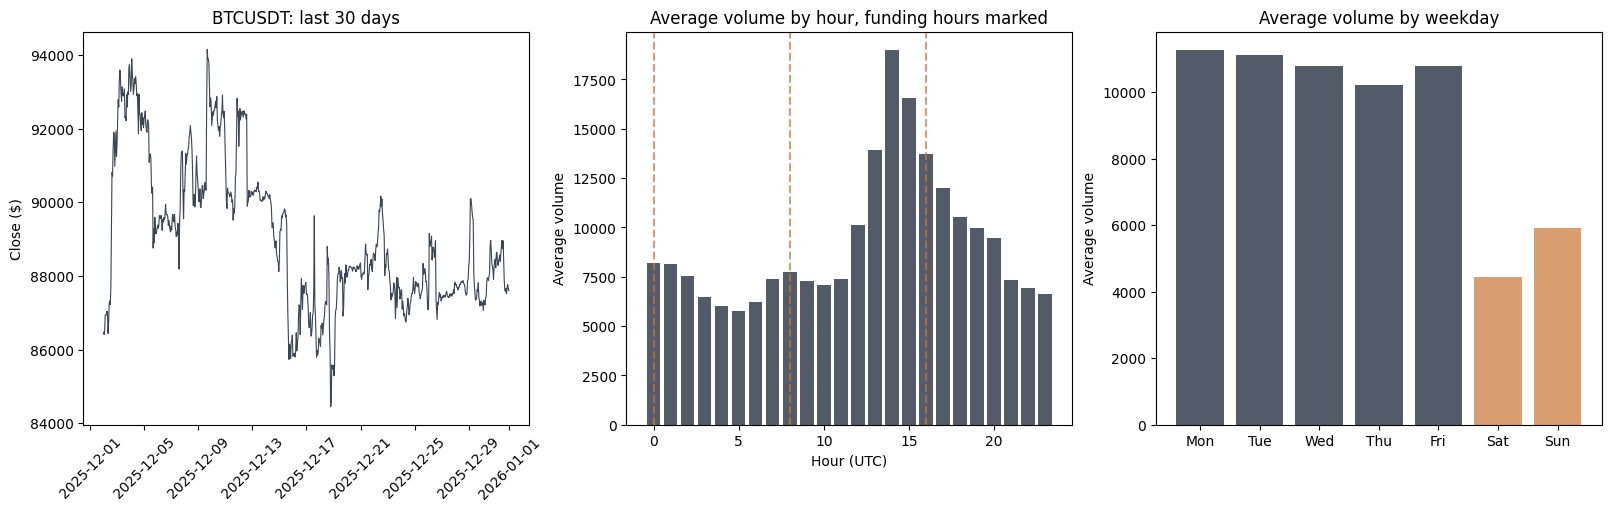

In [19]:
# Visualize crypto data patterns: price series + hourly/daily volume profile
btc_data = crypto_results["BTCUSDT"]["data"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Panel 1: last 30 days of close
recent_data = btc_data.tail(24 * RECENT_DAYS)
axes[0].plot(
    recent_data["timestamp"].to_list(),
    recent_data["close"].to_list(),
    linewidth=0.8,
    alpha=0.8,
    color=COLORS["blue"],
)
axes[0].set_ylabel("Close ($)")
axes[0].set_title(f"{CRYPTO_SYMBOLS[0]}: last {RECENT_DAYS} days")
axes[0].tick_params(axis="x", rotation=45)

# Panel 2: average volume by hour, with funding windows highlighted
hourly_volume = (
    btc_data.group_by("hour_utc").agg(pl.col("volume").mean().alias("avg_volume")).sort("hour_utc")
)
axes[1].bar(
    hourly_volume["hour_utc"].to_list(),
    hourly_volume["avg_volume"].to_list(),
    color=COLORS["blue"],
    alpha=0.7,
)
for funding_hour in FUNDING_HOURS_UTC:
    axes[1].axvline(funding_hour, color=COLORS["copper"], linestyle="--", alpha=0.7)
axes[1].set_ylabel("Average volume")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_title("Average volume by hour, funding hours marked")

# Panel 3: average volume by weekday (weekend in red)
daily_volume = (
    btc_data.group_by("day_of_week")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("day_of_week")
)
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
colors = [COLORS["blue"]] * 5 + [COLORS["copper"]] * 2
axes[2].bar(range(7), daily_volume["avg_volume"].to_list(), color=colors, alpha=0.7)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(days)
axes[2].set_ylabel("Average volume")
axes[2].set_title("Average volume by weekday")

show_with_alt(
    fig,
    "Three panels. The left is an hourly price line over the most recent month. The middle "
    "is a bar per hour of the day showing average volume, with dashed vertical lines at the "
    "three funding hours; the bars vary across the day without an obvious peak at those "
    "lines. The right is a bar per weekday in two colours for weekdays and weekend, with "
    "the two weekend bars shorter than the five weekday bars.",
)

---

## 4. Storage Best Practices

### Partitioned Parquet Storage

For large datasets, partition by time and symbol:

```
output/
└── etf_momentum/
    ├── year=2024/
    │   ├── SPY.parquet
    │   ├── QQQ.parquet
    │   └── TLT.parquet
    └── year=2023/
        └── ...
```

**Benefits**:
- **Partition pruning**: Only read needed date ranges
- **Incremental writes**: Add new data without rewriting
- **Parallel reads**: Process multiple partitions concurrently

In [20]:
# Save pipeline outputs (example)
print("Storage Example:")
print(f"  ETF output: {display_path(etf_pipeline.storage_path)}")
print(f"  Crypto output: {display_path(crypto_pipeline.storage_path)}")

Storage Example:
  ETF output: 02_financial_data_universe/output/etf_pipeline
  Crypto output: 02_financial_data_universe/output/crypto_pipeline


---

## 5. Simplifying with DataManager

The pipelines above show every step explicitly. In practice, ml4t-data's
`DataManager` and `Universe` classes handle most of this boilerplate.
Here's how the ETF pipeline looks using the higher-level API:

In [21]:
from ml4t.data import DataManager
from ml4t.data.storage import HiveStorage
from ml4t.data.storage.backend import StorageConfig
from ml4t.data.universe import Universe
from ml4t.data.update_manager import GapDetector
from ml4t.data.validation import OHLCVValidator

# One-line universe instead of hardcoded list
Universe.add_custom("etf_momentum", ["SPY", "QQQ", "IWM", "TLT", "GLD"])
print(f"Universe: {Universe.get('etf_momentum')}")

# DataManager with storage — fetch, store, and validate in one step
dm_config = StorageConfig(base_path=get_output_dir(2, "dm_pipeline"), compression="zstd")
dm_storage = HiveStorage(config=dm_config)
dm = DataManager(storage=dm_storage, enable_validation=True)

# Fetch and store all symbols
for symbol in Universe.get("etf_momentum"):
    key = dm.load(symbol, "2024-01-01", AS_OF_DATE, provider="yahoo")
    meta = dm.get_metadata(symbol)
    rows = meta.get("row_count", "?") if meta else "?"
    print(f"  {symbol}: {rows} rows → {key}")

Universe: ['SPY', 'QQQ', 'IWM', 'TLT', 'GLD']
2026-09-10 13:05:31 [debug    ] Applied ALPACA_API_KEY to alpaca.api_key


2026-09-10 13:05:31 [debug    ] Applied FRED_API_KEY to fred.api_key


2026-09-10 13:05:31 [debug    ] Applied OANDA_API_KEY to oanda.api_key


2026-09-10 13:05:31 [debug    ] Applied DATABENTO_API_KEY to databento.api_key


2026-09-10 13:05:31 [debug    ] ConfigManager initialized      config_path=None output_format=polars


...

2026-09-10 13:05:33 [warning  ] Data already exists for equities/daily/GLD, overwriting


2026-09-10 13:05:33 [info     ] Storing data for GLD           progress=80%


2026-09-10 13:05:33 [info     ] Data load completed            key=equities/daily/GLD rows=261


2026-09-10 13:05:33 [info     ] Completed loading GLD          progress=100%


  GLD: 261 rows → equities/daily/GLD


In [22]:
# Validate and check gaps — compare to the manual validate_data() above
validator = OHLCVValidator(max_return_threshold=0.5)
gap_detector = GapDetector(exclude_weekends=True)

for symbol in Universe.get("etf_momentum"):
    key = f"equities/daily/{symbol}"
    if dm_storage.exists(key):
        df = dm_storage.read(key).collect()

        result = validator.validate(df)
        gaps = gap_detector.detect_gaps(df, frequency="daily")

        status = "OK" if result.passed else f"{result.error_count} issues"
        gap_status = f"{len(gaps)} gaps" if gaps else "complete"
        print(f"  {symbol}: {len(df)} rows, {status}, {gap_status}")

  SPY: 261 rows, 1 issues, 11 gaps
  QQQ: 261 rows, 1 issues, 11 gaps
  IWM: 261 rows, 1 issues, 11 gaps
  TLT: 261 rows, 1 issues, 11 gaps
  GLD: 261 rows, 1 issues, 11 gaps


The DataManager version replaces ~100 lines of manual provider instantiation,
data combination, and validation with a few lines. Under the hood it uses
the same providers and validation — see notebooks `17_data_management` and
`18_incremental_updates` for the full walkthrough.

## Key Takeaways

1. **A stitch is two adjustment bases, not two date ranges.** Filtering each feed at the seam
   and concatenating leaves a step wherever a corporate action fell after the older feed
   stopped, because the older feed could not back-adjust for something it never saw. Both legs
   are dividend-adjusted, so one ratio at the seam removes the difference, and volume takes the
   reciprocal of the same factor.

2. **Tag every row with its source.** A `source` column is what makes the seam visible in the
   figure above, makes a provider mismatch debuggable, and makes a migration reversible. It
   costs one column.

3. **A validator has to match the cadence it is validating.** The equity pipeline treats a
   multi-day gap as an anomaly and the crypto pipeline treats a gap of more than one bar as
   one, because an equity calendar closes and a perpetual futures market does not. Running
   either threshold on the other panel reports the calendar as a fault or misses every outage.

4. **The gaps the equity validator finds are the calendar, and it cannot tell you that.** Each
   symbol's flagged gap is the same market closure, which is a fact about September 2001 rather
   than about the feed. A gap detector locates a discontinuity; deciding what it was takes a
   calendar.

5. **Promote to `DataManager` once the pipeline stops changing.** The explicit classes above
   exist to show what the higher-level API is doing. Section 5 reproduces the same work through
   it, and the production path is the shorter one.

**Next**: `18_data_management` walks the `DataManager`, `Universe`,
and `HiveStorage` API in depth; `19_incremental_updates` shows the
gap-detection + update-strategy patterns that make daily refreshes
cheap.